# USANDO O APPLE DEPTH PRO

In [4]:
!git clone https://github.com/apple/ml-depth-pro
%cd ml-depth-pro
!pip install -e .

c:\Repositorios\ModernComputerVision\EstimacaoDeProfundidade\DepthPro\ml-depth-pro


Cloning into 'ml-depth-pro'...


Obtaining file:///C:/Repositorios/ModernComputerVision/EstimacaoDeProfundidade/DepthPro/ml-depth-pro
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Checking if build backend supports build_editable: started
  Checking if build backend supports build_editable: finished with status 'done'
  Getting requirements to build editable: started
  Getting requirements to build editable: finished with status 'done'
  Preparing editable metadata (pyproject.toml): started
  Preparing editable metadata (pyproject.toml): finished with status 'done'
  Using cached numpy-1.26.4.tar.gz (15.8 MB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Installing backend dependencies: started
  Installing backend dependencies: finished with status 'done'
  Preparing metadata (pyproject.toml

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
roboflow 1.1.58 requires opencv-python-headless==4.10.0.84, which is not installed.
ml-dtypes 0.5.4 requires numpy>=2.1.0; python_version >= "3.13", but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.


#### baixe o modelo

https://ml-site.cdn-apple.com/models/depth-pro/depth_pro.pt

e crie uma pasta chamada checkpoints

In [3]:
from PIL import Image
import depth_pro

# Load model and preprocessing transform
model, transform = depth_pro.create_model_and_transforms()
model.eval()

# Load and preprocess an image.
image, _, f_px = depth_pro.load_rgb("image1.jpeg")
image = transform(image)

# Run inference.
prediction = model.infer(image, f_px=f_px)
depth = prediction["depth"]  # Depth in [m].
focallength_px = prediction["focallength_px"]  # Focal length in pixels.

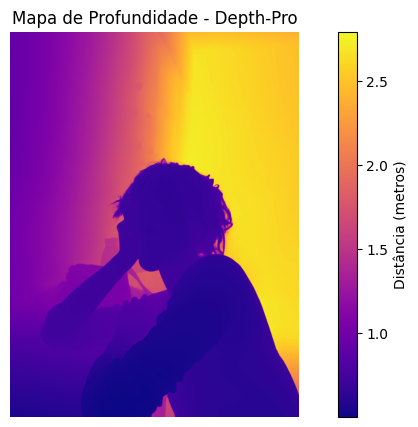

In [5]:
import matplotlib.pyplot as plt

# Converter o tensor para um array numpy
depth_numpy = depth.squeeze().cpu().numpy()

plt.figure(figsize=(10, 5))
# Usamos o mapa de cores 'magma' ou 'plasma' que são ótimos para profundidade
plt.imshow(depth_numpy, cmap='plasma')
plt.colorbar(label='Distância (metros)')
plt.title('Mapa de Profundidade - Depth-Pro')
plt.axis('off')
plt.show()

In [6]:
import cv2
import numpy as np

# Converter para numpy
depth_numpy = depth.squeeze().cpu().numpy()

# Normalizar para o intervalo [0, 255] para visualização
depth_min = depth_numpy.min()
depth_max = depth_numpy.max()
depth_normalized = (depth_numpy - depth_min) / (depth_max - depth_min)
depth_int = (depth_normalized * 255).astype(np.uint8)

# Aplicar um mapa de cores (opcional, mas ajuda muito no visual)
depth_color = cv2.applyColorMap(depth_int, cv2.COLORMAP_JET)

# Salvar ou mostrar
cv2.imwrite('depth_output.png', depth_color)
# cv2.imshow('Depth', depth_color); cv2.waitKey(0)

True